## Unsupervised Analysis of Killer Whale Calls

**IISER Advanced Bioacoustics Workshop**

*February 3rd, 2026*

In [ ]:
## --- import some libraries --- ##

import numpy as np  # for numerical calculations
import pandas as pd  # for working with csv files and data frames
from matplotlib import pyplot as plt  # for plotting and visualization
import datetime # for parsing and formatting date/time data

### Formatting

First, parse and re-format the BirdNET embedding files to a format read by the Tensorflow visualizer.

In [2]:
# load in the BirdNET embeddings and take a look at them
embeddings_file = '../Data/embeddings.csv'
embeddings = pd.read_csv(embeddings_file, sep=',')
embeddings.head()

,file_path,start,end,embedding
0,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.03765869140625,0.63134765625,0.0530395507812..."
1,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.247314453125,0.6484375,0.216064453125,0.0598..."
2,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.086669921875,0.145751953125,0.32568359375,0...."
3,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.03326416015625,0.59814453125,0.1280517578125..."
4,/Users/ivt2/Documents/2026/IndiaWorkshop/IISER...,0.0,3.0,"0.08770751953125,0.7216796875,0.184814453125,0..."


In [3]:
# extract the numerical part into a matrix, and save to a txt file
numbers = embeddings['embedding']
numbers = np.array([[float(x) for x in num.split(',')] for num in numbers])
np.savetxt('..embedding_values.tsv', numbers, delimiter='\t')

In [6]:
# parse and reformat the metadata
def parseMetadata(filename):
    split_path = filename.split('/')
    split_filename = split_path[-1].split('_')
    category = split_filename[-1][:-4]
    day = split_filename[0]
    channel = split_filename[2]
    time = split_filename[3][:-1]
    return category, day, channel, time

# apply parsing function
metadata = pd.DataFrame(embeddings['file_path'].apply(parseMetadata).tolist())

# set columns names
metadata.columns = ['Category', 'Day', 'Channel', 'Time']

# save to tab-separated file
metadata.to_csv('metadata.tsv', sep='\t', index=False)

In [8]:
# take only the part of the embeddings for the noise files
noise_embeddings = embeddings[['noise' in embeddings['file_path'].iloc[i] for i in range(len(embeddings))]]

# extract the numerical part into a matrix, and save to a txt file
noise_numbers = noise_embeddings['embedding']
noise_numbers = np.array([[float(x) for x in num.split(',')] for num in noise_numbers])
np.savetxt('noise_embedding_values.tsv', noise_numbers, delimiter='\t')

In [9]:
# apply parsing function
noise_metadata = pd.DataFrame(noise_embeddings['file_path'].apply(parseMetadata).tolist())

# set columns names
noise_metadata.columns = ['Category', 'Day', 'Channel', 'Time']

# save to tab-separated file
noise_metadata.to_csv('noise_metadata.tsv', sep='\t', index=False)

### Calculate and Visualize Projections

In [10]:
from sklearn.decomposition import PCA # for principal component analysis
from sklearn.manifold import TSNE # for t-distributed stochastic neighbor embedding
import umap # for uniform manifold approximation and projection

Next, calculate PCA projection:

In [11]:
projection_pca = PCA(n_components=2).fit_transform(numbers)

Calculate t-SNE projection:

In [12]:
projection_tsne = TSNE(n_components=2).fit_transform(numbers)

Calculate UMAP projection:

In [13]:
projection_umap = umap.UMAP(n_components=2).fit_transform(numbers)

Now plot and visualize the output, considering the relative distribution and tightness of clusters.

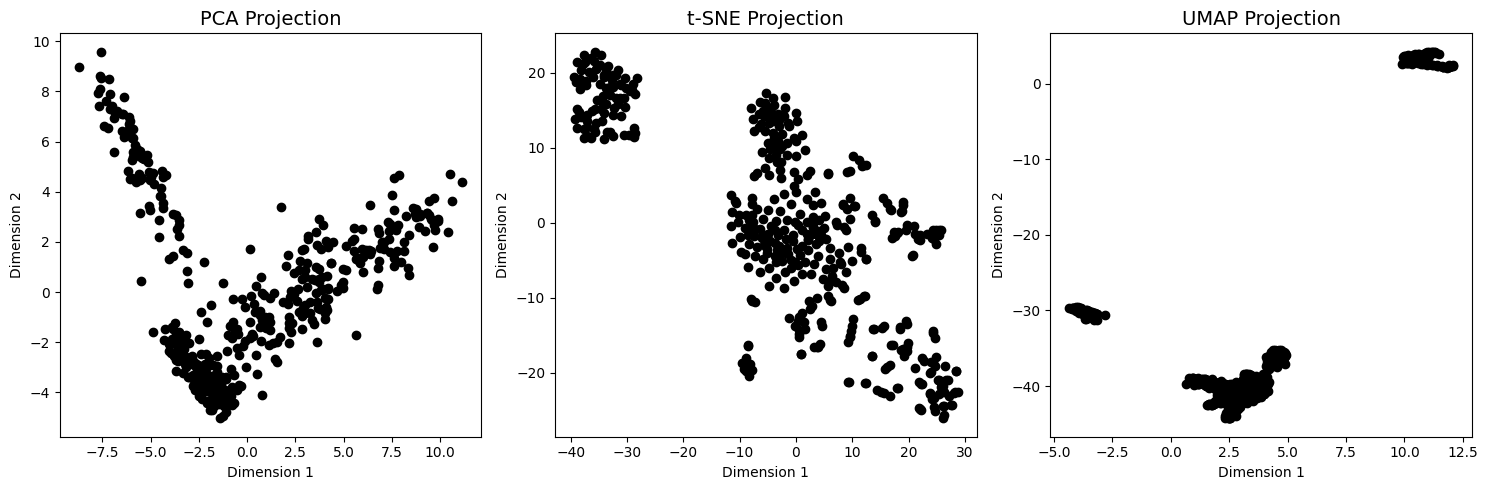

In [14]:
methods = ['PCA', 't-SNE', 'UMAP']
projections = {'PCA': projection_pca, 't-SNE': projection_tsne, 'UMAP': projection_umap}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    axs[i].scatter(projections[methods[i]][:, 0], projections[methods[i]][:, 1], c='k', marker='o')
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)

plt.tight_layout()

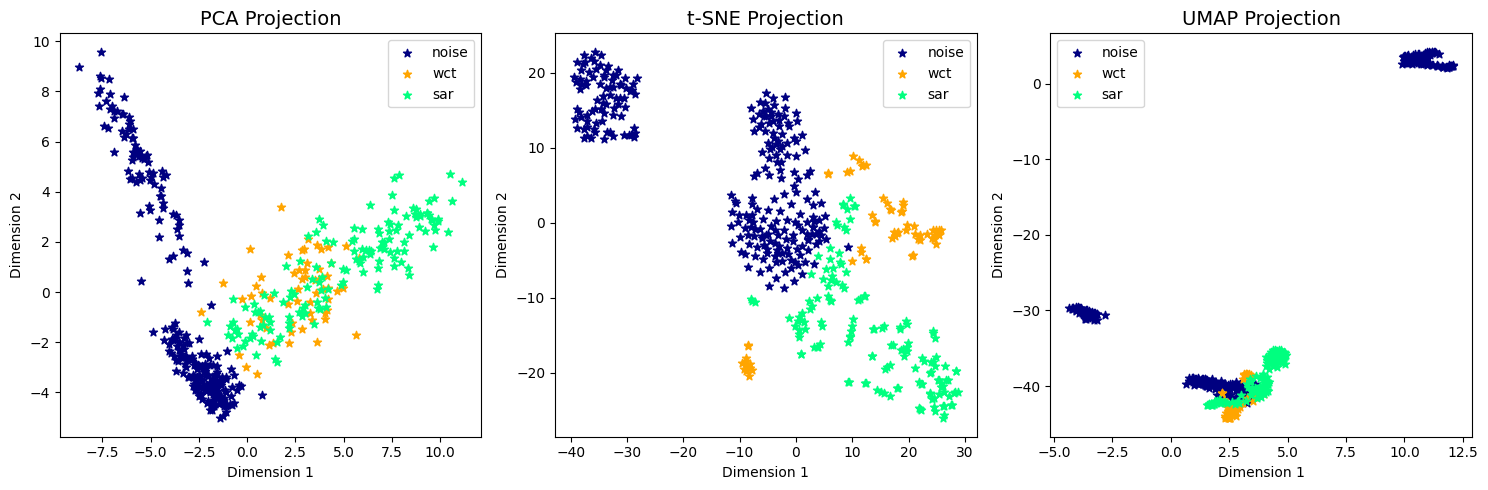

In [15]:
colors = {'noise': 'navy', 'wct': 'orange', 'sar': 'springgreen'}

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i in range(3):
    for category in ['noise', 'wct', 'sar']:
        axs[i].scatter(projections[methods[i]][metadata['Category'] == category, 0], projections[methods[i]][metadata['Category'] == category, 1], c=colors[category], marker='*', label=category)
    
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)
    axs[i].legend()

plt.tight_layout()

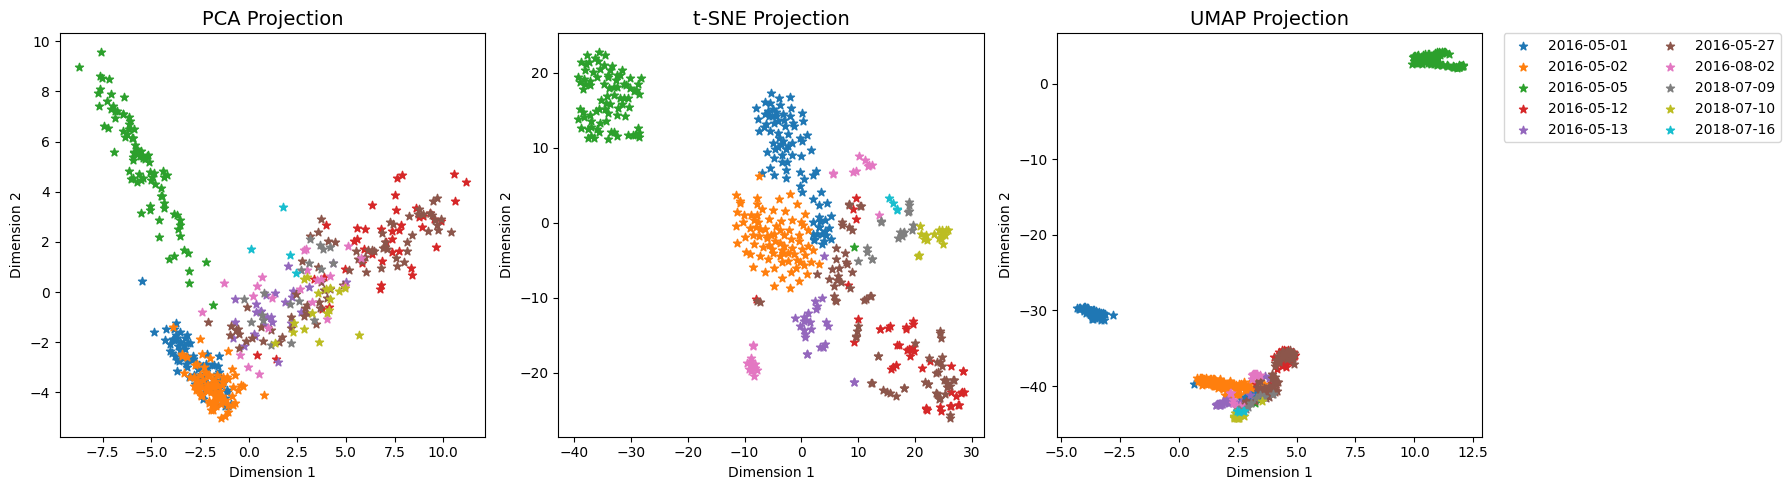

In [16]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))
for i in range(3):
    for day in metadata['Day'].unique():
        axs[i].scatter(projections[methods[i]][metadata['Day'] == day, 0], projections[methods[i]][metadata['Day'] == day, 1], marker='*', label=datetime.datetime.strptime(day, '%Y%m%d').strftime('%Y-%m-%d'))
    
    axs[i].set_xlabel('Dimension 1')
    axs[i].set_ylabel('Dimension 2')
    axs[i].set_title('%s Projection' % methods[i], fontsize=14)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., ncol=2)
plt.tight_layout()